In [6]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = init_chat_model(
    "gpt-5-nano",
    temperature=0,
    api_key="a",
    base_url="http://127.0.0.1:8080/v1"
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [7]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [8]:
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

In [9]:
from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [11]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

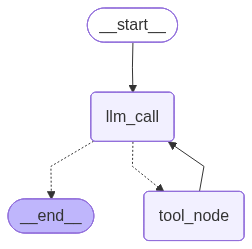

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (FUVqebeG4dJ2RNemluE2VVUghE7miuQq)
 Call ID: FUVqebeG4dJ2RNemluE2VVUghE7miuQq
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [12]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [13]:
import requests

In [26]:

import requests
import json

base_url = "http://localhost:8000/v1/chat/completions"
headers = {"Content-Type": "application/json"}
data = {
    "model": "gpt-4",
    "messages": [{"role": "user", "content": "How is the weather in New York?"}],
    "stream": True,
    "extra_body": {
    "get_weather.temperature": "celsius"
  }
}

response = requests.post(base_url, headers=headers, json=data, stream=True)
run_id = response.headers.get("X-Run-Id", "?")
print(f"── Run {run_id} ─────────────────────────────────────────")

answer_buf = []

for raw_line in response.iter_lines():
    if not raw_line:
        continue
    line = raw_line.decode("utf-8")
    if not line.startswith("data:"):
        continue
    payload = line[len("data:"):].strip()
    if payload == "[DONE]":
        break

    try:
        chunk = json.loads(payload)
    except json.JSONDecodeError:
        continue

    # ── tool call / result events (custom extension) ──────────────
    if chunk.get("type") == "tool_call":
        args = json.dumps(chunk.get("input", {}))
        print(f"\n🔧 TOOL CALL   {chunk['name']}({args})")
        continue

    if chunk.get("type") == "tool_result":
        print(f"📥 TOOL RESULT {chunk['name']} → {chunk['output']}")
        continue

    # ── regular content delta ──────────────────────────────────────
    for choice in chunk.get("choices", []):
        delta = choice.get("delta", {})
        token = delta.get("content") or ""
        if token:
            print(token, end="", flush=True)
            answer_buf.append(token)

print(f"\n── Done ─────────────────────────────────────────────────")
print(f"Full answer: {''.join(answer_buf)}")


── Run 62fd5053-85df-4e3c-a177-90efa11896ae ─────────────────────────────────────────

🔧 TOOL CALL   get_weather({"city": "New York"})
📥 TOOL RESULT get_weather → Weather in New York:
  Temperature : 37°C (feels like 34°C)
  Condition   : Snow
  Humidity    : 23%
  Wind Speed  : 75 km/h
  [simulated data]
The weather in New York is currently snowy with a temperature of 37°C (feels like 34°C). Humidity is at 23%, and wind speed is 75 km/h. 

*Note: This is simulated data.*
── Done ─────────────────────────────────────────────────
Full answer: The weather in New York is currently snowy with a temperature of 37°C (feels like 34°C). Humidity is at 23%, and wind speed is 75 km/h. 

*Note: This is simulated data.*


In [1]:
#test canceling after 1s
import time
import requests
base_url = "http://localhost:8000/v1/chat/completions"
headers = {"Content-Type": "application/json"}
data = {
    "model": "gpt-4",
    "messages": [{"role": "user", "content": "Write a long story."}],
    "stream": True,
}
response = requests.post(base_url, headers=headers, json=data, stream=True)
run_id = response.headers.get("X-Run-Id", "?")

print(f"── Run {run_id} ─────────────────────────────────────────")
for raw_line in response.iter_lines():
    if not raw_line:
        continue
    line = raw_line.decode("utf-8")
    if not line.startswith("data:"):
        continue
    payload = line[len("data:"):].strip()
    print(payload)

── Run bc5b3dd3-15ea-4e96-b368-2d32ef49bd7c ─────────────────────────────────────────
{"id":"chatcmpl-bc5b3dd3-15ea-4e96-b368-2d32ef49bd7c","object":"chat.completion.chunk","created":1773125585,"model":"gpt-4","choices":[{"index":0,"delta":{"role":"assistant","content":null,"tool_calls":null},"finish_reason":null,"logprobs":null}],"system_fingerprint":null}
{"id":"chatcmpl-bc5b3dd3-15ea-4e96-b368-2d32ef49bd7c","object":"chat.completion.chunk","created":1773125585,"model":"gpt-4","choices":[{"index":0,"delta":{"role":null,"content":"Once","tool_calls":null},"finish_reason":null,"logprobs":null}],"system_fingerprint":null}
{"id":"chatcmpl-bc5b3dd3-15ea-4e96-b368-2d32ef49bd7c","object":"chat.completion.chunk","created":1773125585,"model":"gpt-4","choices":[{"index":0,"delta":{"role":null,"content":" upon","tool_calls":null},"finish_reason":null,"logprobs":null}],"system_fingerprint":null}
{"id":"chatcmpl-bc5b3dd3-15ea-4e96-b368-2d32ef49bd7c","object":"chat.completion.chunk","created":1773

KeyboardInterrupt: 